# 전처리 후 데이터 EDA 시각화

`src/data_preprocessing.py`가 생성한 `data/processed/clean_train_with_ids.csv`를 대상으로 요금 분포, 범주별 비교, 상관관계와 시간·지역 패턴을 확인한다. 원본 데이터 EDA와 구분되는 정제 후 시각화 단계이며 모델 학습은 수행하지 않는다.


**데이터 로드 및 한글폰트 설치**

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# ---- 데이터 로드 ----
df = pd.read_csv('taxi_analysis_pipeline/data/processed/clean_train_with_ids.csv')
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

print(df.shape)
df.head()

(763225, 8)


,VendorID,tpep_pickup_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,fare_ex_tip
0,2,2026-05-01 00:04:59,1.0,7.51,1.0,138.0,37.0,45.40
1,2,2026-05-01 00:37:05,1.0,6.14,1.0,138.0,237.0,40.25
2,1,2026-05-01 00:34:05,1.0,2.40,1.0,249.0,232.0,24.85
3,1,2026-05-01 00:55:07,1.0,1.20,1.0,232.0,114.0,15.05
4,2,2026-05-01 00:24:35,1.0,5.89,1.0,255.0,236.0,33.90


In [7]:
# 한글 폰트 설치 및 설정 (코랩 전용)
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

1. Y 분포 (fare_ex_tip) — Seaborn 히스토그램

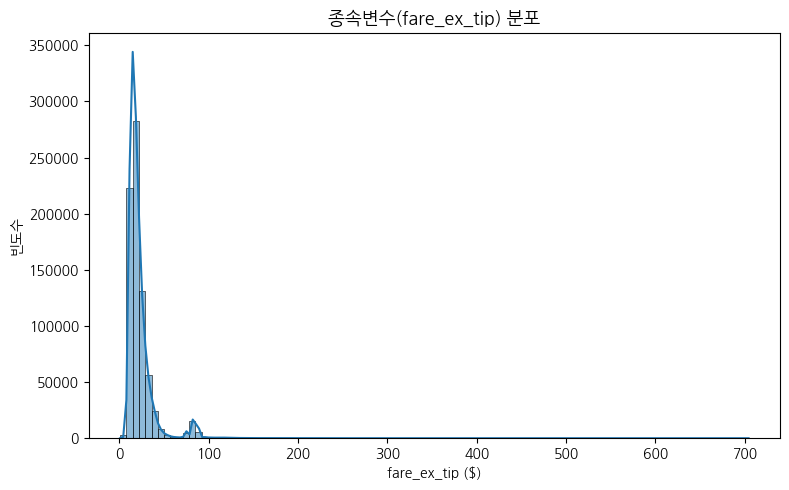

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['fare_ex_tip'], bins=100, kde=True)
plt.title('종속변수(fare_ex_tip) 분포', fontsize=13)
plt.xlabel('fare_ex_tip ($)')
plt.ylabel('빈도수')
plt.tight_layout()
plt.savefig('01_fare_distribution.png', dpi=150)
plt.show()

2. RatecodeID별 요금 비교 — Seaborn boxplot (그룹비교)

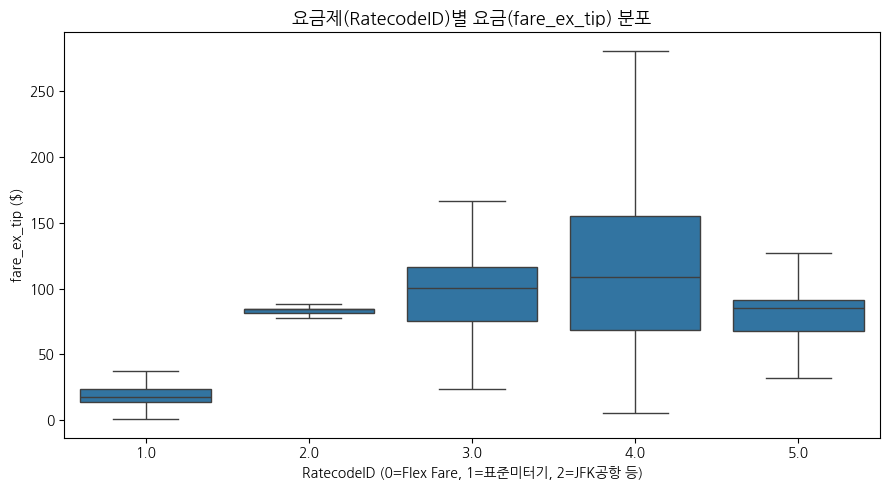

In [10]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='RatecodeID', y='fare_ex_tip', showfliers=False)
plt.title('요금제(RatecodeID)별 요금(fare_ex_tip) 분포', fontsize=13)
plt.xlabel('RatecodeID (0=Flex Fare, 1=표준미터기, 2=JFK공항 등)')
plt.ylabel('fare_ex_tip ($)')
plt.tight_layout()
plt.savefig('02_ratecode_boxplot.png', dpi=150)
plt.show()

3. VendorID별 요금 비교 — Seaborn barplot (그룹비교)

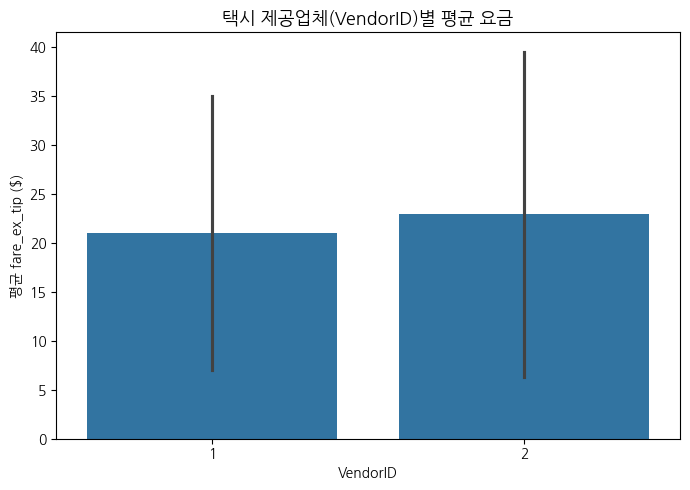

In [11]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='VendorID', y='fare_ex_tip', errorbar='sd')
plt.title('택시 제공업체(VendorID)별 평균 요금', fontsize=13)
plt.xlabel('VendorID')
plt.ylabel('평균 fare_ex_tip ($)')
plt.tight_layout()
plt.savefig('03_vendor_barplot.png', dpi=150)
plt.show()

4. 수치형 변수 상관관계 — Seaborn heatmap (상관관계)

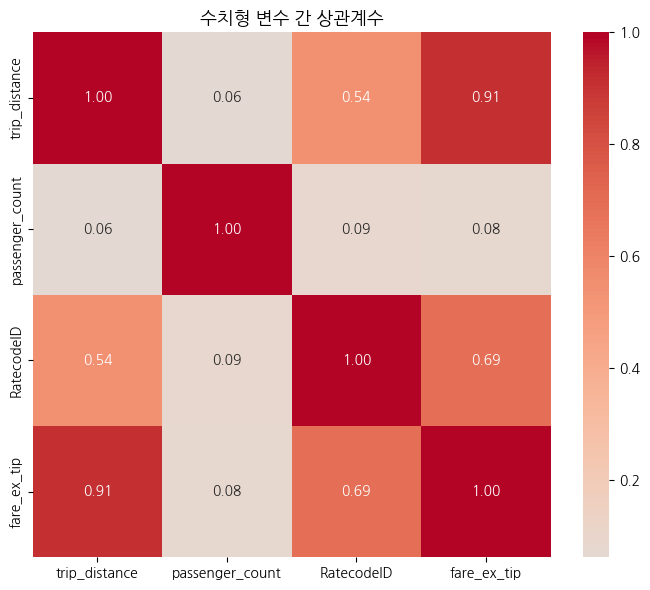

In [12]:
plt.figure(figsize=(7,6))
corr = df[['trip_distance','passenger_count','RatecodeID','fare_ex_tip']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 변수 간 상관계수', fontsize=13)
plt.tight_layout()
plt.savefig('04_corr_heatmap.png', dpi=150)
plt.show()

5. 거리 vs 요금 — Plotly scatter (상관관계, 인터랙티브)

In [13]:
sample = df.sample(20000, random_state=42)

fig = px.scatter(
    sample, x='trip_distance', y='fare_ex_tip',
    color='RatecodeID',
    title='운행거리(trip_distance)와 요금(fare_ex_tip)의 관계 (RatecodeID별)',
    labels={'trip_distance':'운행거리 (마일)', 'fare_ex_tip':'요금 ($)', 'RatecodeID':'RatecodeID'},
    opacity=0.5
)
fig.update_layout(title_x=0.5)
fig.show()
fig.write_html('05_distance_fare_scatter.html')

6. 승차 시각(시간대) 패턴 — Plotly line (분포, 인터랙티브)

In [14]:
tmp = df.copy()
tmp['hour'] = tmp['tpep_pickup_datetime'].dt.hour
hourly = tmp.groupby('hour').agg(trip_count=('fare_ex_tip','count'), avg_fare=('fare_ex_tip','mean')).reset_index()

fig2 = px.line(
    hourly, x='hour', y='trip_count',
    title='시간대별 트립 건수 (승차 시각 기준)',
    labels={'hour':'시간 (0~23시)', 'trip_count':'트립 건수'},
    markers=True
)
fig2.update_layout(title_x=0.5)
fig2.show()
fig2.write_html('06_hourly_pattern.html')

7. 승차 지역(PULocationID) 상위 10개 — Seaborn barplot (그룹비교)

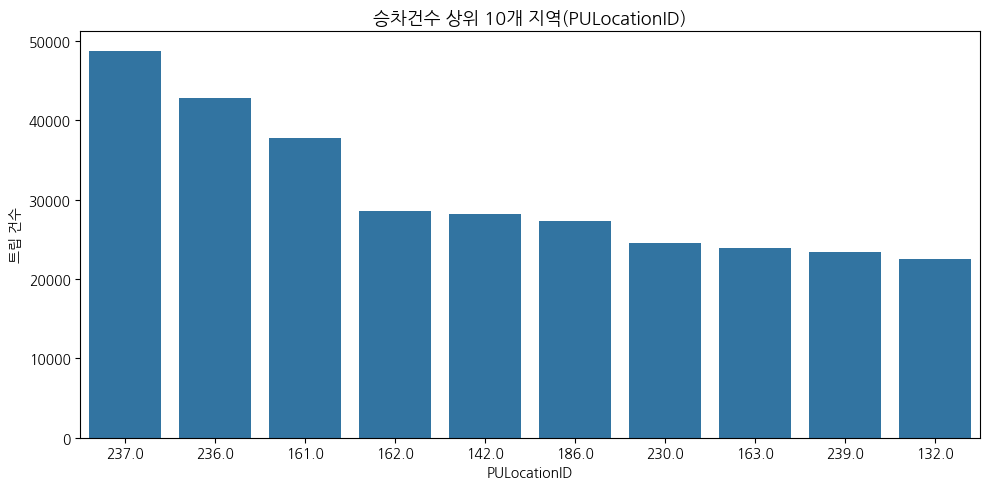

In [15]:
top10 = df['PULocationID'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top10.index.astype(str), y=top10.values)
plt.title('승차건수 상위 10개 지역(PULocationID)', fontsize=13)
plt.xlabel('PULocationID')
plt.ylabel('트립 건수')
plt.tight_layout()
plt.savefig('07_top_pu_zones.png', dpi=150)
plt.show()

8. 승객수별 요금 — Seaborn boxplot (그룹비교)

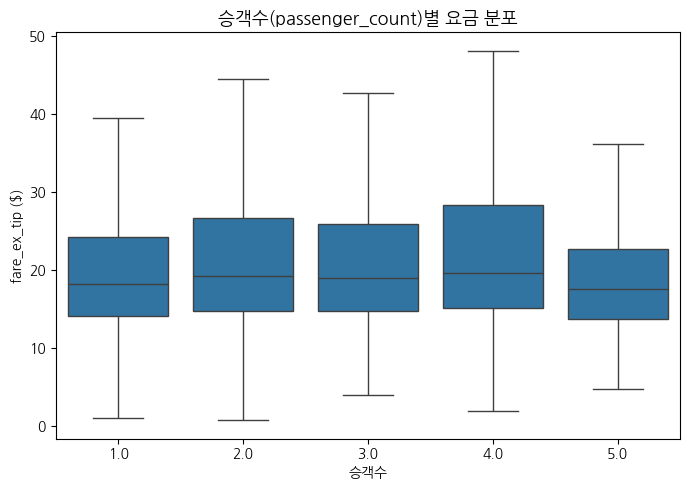

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='passenger_count', y='fare_ex_tip', showfliers=False)
plt.title('승객수(passenger_count)별 요금 분포', fontsize=13)
plt.xlabel('승객수')
plt.ylabel('fare_ex_tip ($)')
plt.tight_layout()
plt.savefig('08_passenger_boxplot.png', dpi=150)
plt.show()